Load the Cleaned Data

In [5]:
import pandas as pd

benin = pd.read_csv("../data/benin_clean.csv")
sierra = pd.read_csv("../data/sierraleone_clean.csv")
togo = pd.read_csv("../data/togo_clean.csv")

benin["country"] = "Benin"
sierra["country"] = "Sierra Leone"
togo["country"] = "Togo"

df_all = pd.concat([benin, sierra, togo])

Boxplots of GHI , DNI, DHI per Country

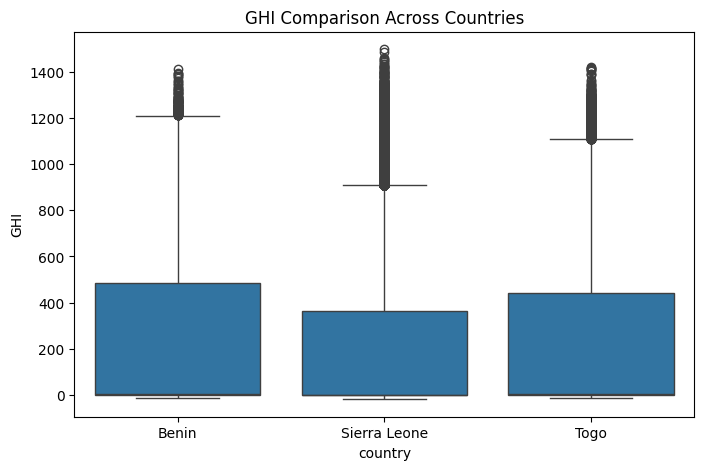

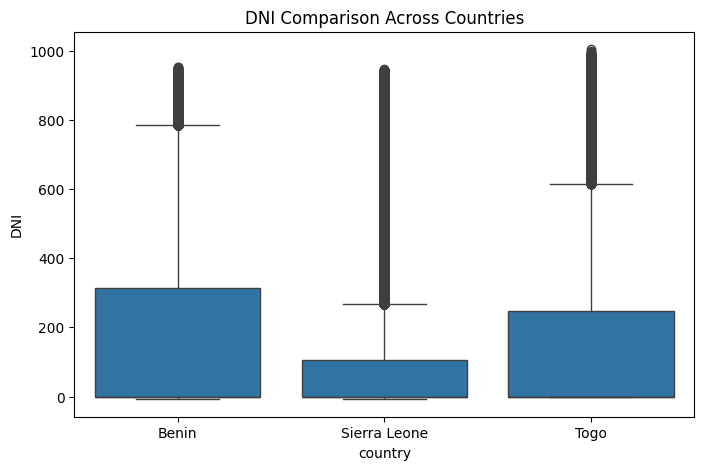

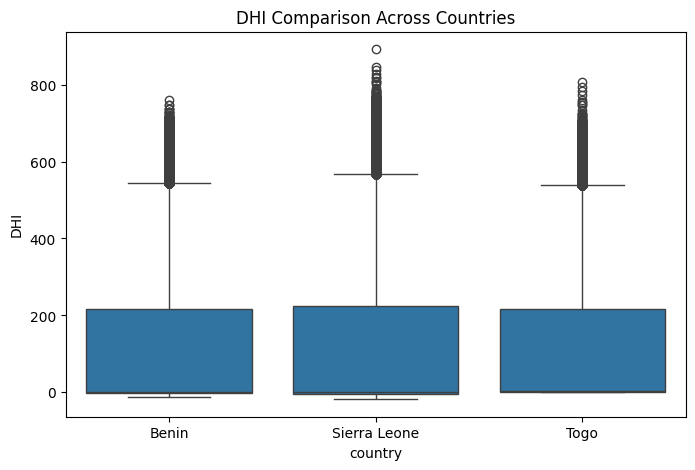

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

for metric in ["GHI", "DNI", "DHI"]:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x="country", y=metric, data=df_all)
    plt.title(f"{metric} Comparison Across Countries")
    plt.show()

Summary statistics

In [7]:
summary = df_all.groupby("country")[["GHI", "DNI", "DHI"]].agg(["mean", "median", "std"])
summary

GHI                            DNI                     \
                    mean median         std        mean median         std   
country                                                                      
Benin         240.559452    1.8  331.131327  167.187516   -0.1  261.710501   
Sierra Leone  201.957515    0.3  298.495150  116.376337   -0.1  218.652659   
Togo          230.555040    2.1  322.532347  151.258469    0.0  250.956962   

                     DHI                     
                    mean median         std  
country                                      
Benin         115.358961    1.6  158.691074  
Sierra Leone  113.720571   -0.1  158.946032  
Togo          116.444352    2.5  156.520714

Statistical TEst(ANOVA or Kruskal_wallis)

In [8]:
from scipy.stats import f_oneway

f_oneway(
    benin["GHI"].dropna(),
    sierra["GHI"].dropna(),
    togo["GHI"].dropna()
)

F_onewayResult(statistic=np.float64(2090.092870479632), pvalue=np.float64(0.0))

Visual Summary

<Axes: xlabel='country'>

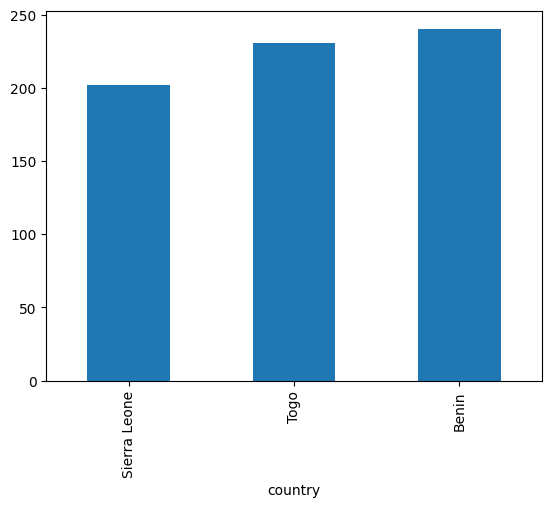

In [9]:
df_all.groupby("country")["GHI"].mean().sort_values().plot(kind="bar")

Benin has the highest average GHI among the three countries, suggesting the greatest solar potential.
Togo ranks second, with slightly lower GHI values than Benin, but still favorable for solar applications.
Sierra Leone has the lowest average GHI, indicating comparatively less solar irradiance, but still a viable candidate for solar energy with proper planning.